In [1]:
# General
import numpy as np
import scipy
import os
import pickle as pickle
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import io

# Specific
from dmd_laughlin_3 import holo_maker
from dmd_laughlin_3 import DMDwrapper
from dmd_laughlin_3 import master_helper

UpperModeProfiles dir is C:\pylab\expctl\src\expctl\servers\dmd\dmd_laughlin_3\UpperModeProfiles
caching mode C:\pylab\expctl\src\expctl\servers\dmd\dmd_laughlin_3\UpperModeProfiles\mode_0,0.txt
caching mode C:\pylab\expctl\src\expctl\servers\dmd\dmd_laughlin_3\UpperModeProfiles\mode_0,1.txt
caching mode C:\pylab\expctl\src\expctl\servers\dmd\dmd_laughlin_3\UpperModeProfiles\mode_0,10.txt
caching mode C:\pylab\expctl\src\expctl\servers\dmd\dmd_laughlin_3\UpperModeProfiles\mode_0,11.txt
caching mode C:\pylab\expctl\src\expctl\servers\dmd\dmd_laughlin_3\UpperModeProfiles\mode_0,12.txt
caching mode C:\pylab\expctl\src\expctl\servers\dmd\dmd_laughlin_3\UpperModeProfiles\mode_0,13.txt
caching mode C:\pylab\expctl\src\expctl\servers\dmd\dmd_laughlin_3\UpperModeProfiles\mode_0,14.txt
caching mode C:\pylab\expctl\src\expctl\servers\dmd\dmd_laughlin_3\UpperModeProfiles\mode_0,15.txt
caching mode C:\pylab\expctl\src\expctl\servers\dmd\dmd_laughlin_3\UpperModeProfiles\mode_0,16.txt
caching mode C

In [2]:
main_directory_path = master_helper.get_main_directory_path()
maps_directory_path = os.path.join(main_directory_path, "maps")

In [2]:
def initHolomaker(waveperiod, verbose=False):

    MAXNUMROWS = 684
    MAXNUMCOLS = 608

    #phaseMap
    main_directory_path = master_helper.get_main_directory_path()
    maps_directory_path = os.path.join(main_directory_path, "maps")
    #with open(os.path.join(maps_directory_path, "phaseMap_interpolated.txt"), 'r') as f:
    #    phaseMap_interpolated = pickle.load(f)
    phaseMap_interpolated = np.load(os.path.join(maps_directory_path, "phaseMap_interpolated_3.npy"))
    phaseMap_interpolated = np.flipud(phaseMap_interpolated)

    #amplitudeMap
    #phaseMap_interpolated = np.zeros((MAXNUMROWS,MAXNUMCOLS))+0.0
    amplitudeMap_interpolated = np.zeros((MAXNUMROWS,MAXNUMCOLS))+1.0


    #create blank
    a = 2 #sharpness
    d = waveperiod #4 carrier wave period in pixels
    angle_deg = 20.0 # carrier wave direction relative to horizontal (degrees)
    if (verbose):
        print("Initializating holomaker")
    holomaker = holo_maker.holo_maker(0,
                                      phaseMap_interpolated,
                                      amplitudeMap_interpolated,
                                      sharpness=a,
                                      period=d,
                                      angle=angle_deg)
    return holomaker

In [3]:
holomaker = initHolomaker(4, verbose=True)

Initializating holomaker


In [7]:
%load_ext snakeviz

In [4]:
%%timeit
holomaker.resetTargetFunction()

26.9 µs ± 312 ns per loop (mean ± std. dev. of 7 runs, 10000 loops each)


In [11]:
holomaker.addNPC((0.6, 0.55), 0, 0, 75, center=(60,45), defocus=-0.45, tilt=(-0.05,0.35))

In [6]:
hologram = holomaker.makeHologram()

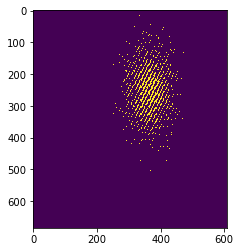

In [7]:
plt.figure()
plt.imshow(hologram, interpolation='none')

In [8]:
im = Image.fromarray(hologram.astype(np.uint8))
buf = io.BytesIO()
im.save(buf, format='BMP')
byte_im = buf.getvalue()

In [9]:
bite_load = open("dmd_laughlin_2/test/hologram0.bmp",'rb').read()

In [10]:
DMDwrapper.display_data(byte_im)

Current display mode: 
Loading image...
    Done.
Connection closed


0

In [18]:
import re

In [19]:
re.search("mode_{[0-9]*},{[0-9]*}.txt", 'mode_22,1.txt')

In [42]:
m = re.match("mode_(\d+),(\d+).txt", 'mode_23,1.txt')

In [44]:
m.groups()

('23', '1')

In [30]:
i

'23'